In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(512, 512)
262144


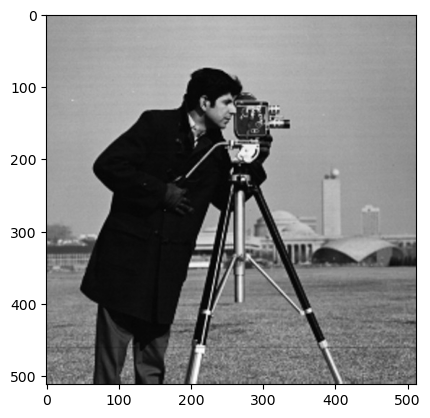

In [2]:
img = cv2.imread('camera.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
print(img.shape)
print(img.size)

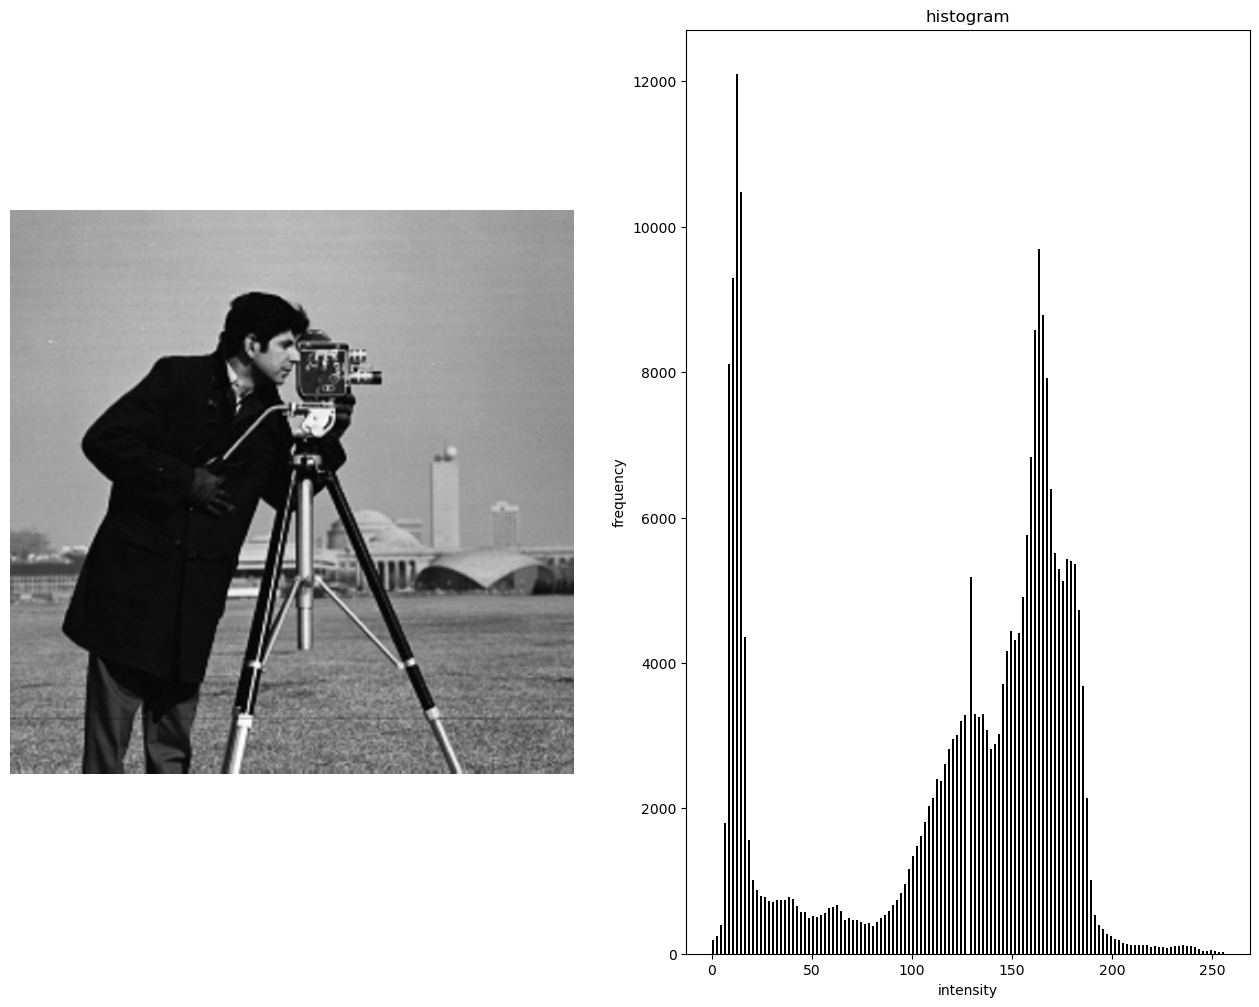

In [3]:
plt.figure(figsize=(16,12))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(img.ravel(), bins=256, range=(0,256), color='black')
plt.title('histogram')
plt.xlabel('intensity')
plt.ylabel('frequency')

plt.show()

(a) Perform the brightness enhancement of a specific range of gray levels and observe its result

(np.float64(-12.8), np.float64(268.8), np.float64(0.0), np.float64(12710.25))

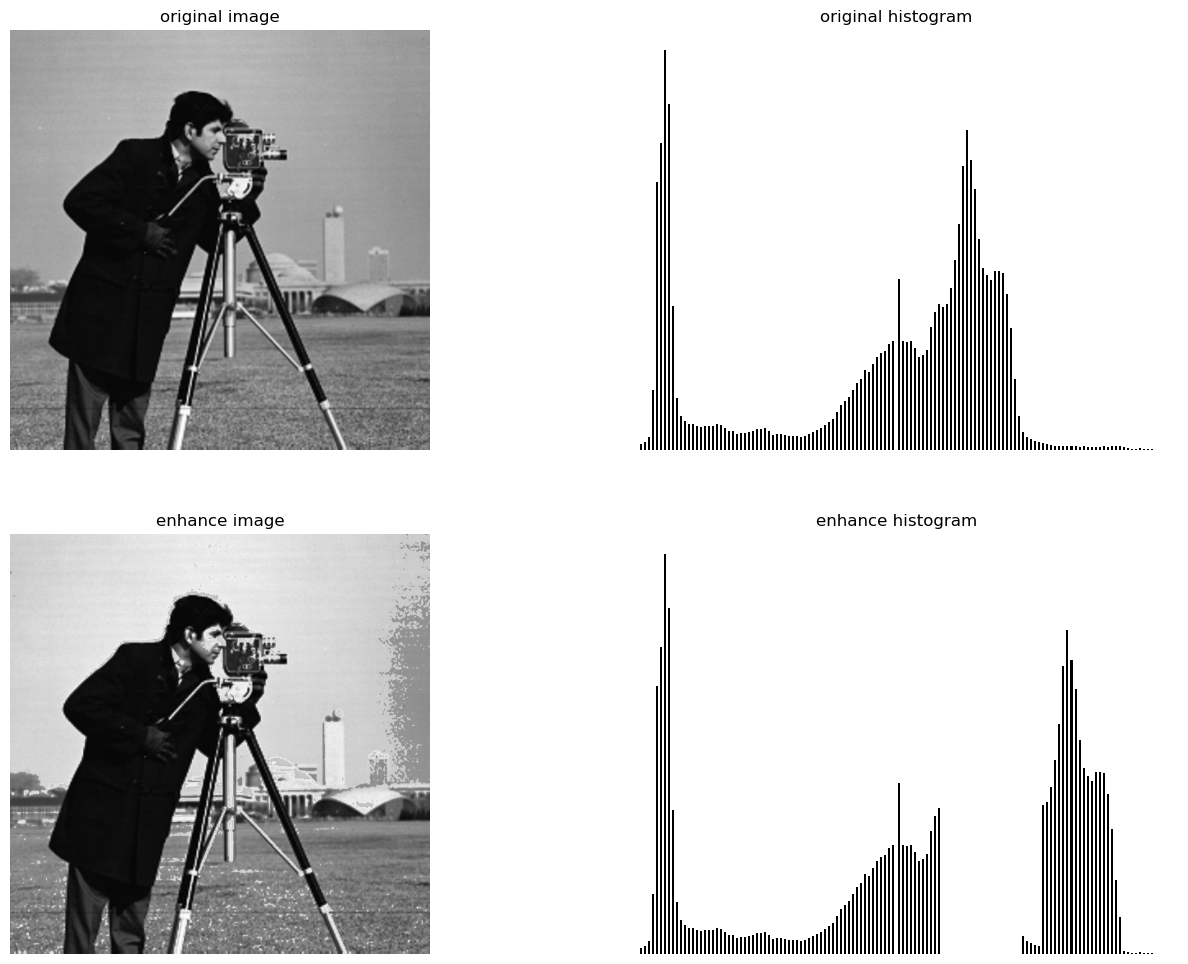

In [4]:
lower_bound = 150
upper_bound = 190
enhance_value = 50

enhance_image = img.copy()

enhance_image[(img>=lower_bound) & (img<upper_bound)] += enhance_value

enhance_image = np.clip(enhance_image, 0, 255)

plt.figure(figsize=(16,12))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('original image')
plt.axis('off')
plt.subplot(2,2,2)
plt.hist(img.ravel(), bins=256, range=(0,256), color='black')
plt.title('original histogram')
plt.xlabel('intensity')
plt.ylabel('frequency')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(enhance_image, cmap='gray')
plt.title('enhance image')
plt.axis('off')
plt.subplot(2,2,4)
plt.hist(enhance_image.ravel(), bins=256, range=(0,256), color='black')
plt.title('enhance histogram')
plt.xlabel('intensity')
plt.ylabel('frequency')
plt.axis('off')

(b) Differentiate the results of power law transform and inverse logarithmic transform

/tmp/ipykernel_4833/348040706.py:1: RuntimeWarning: overflow encountered in scalar add
  c = 255/np.log(1+np.max(img))
/tmp/ipykernel_4833/348040706.py:1: RuntimeWarning: divide by zero encountered in log
  c = 255/np.log(1+np.max(img))
/tmp/ipykernel_4833/348040706.py:2: RuntimeWarning: divide by zero encountered in log
  log_img = c* np.log((1+img))
/tmp/ipykernel_4833/348040706.py:2: RuntimeWarning: invalid value encountered in multiply
  log_img = c* np.log((1+img))
/tmp/ipykernel_4833/348040706.py:3: RuntimeWarning: invalid value encountered in cast
  log_img = log_img.astype(np.uint8)


Text(0, 0.5, 'frequency')

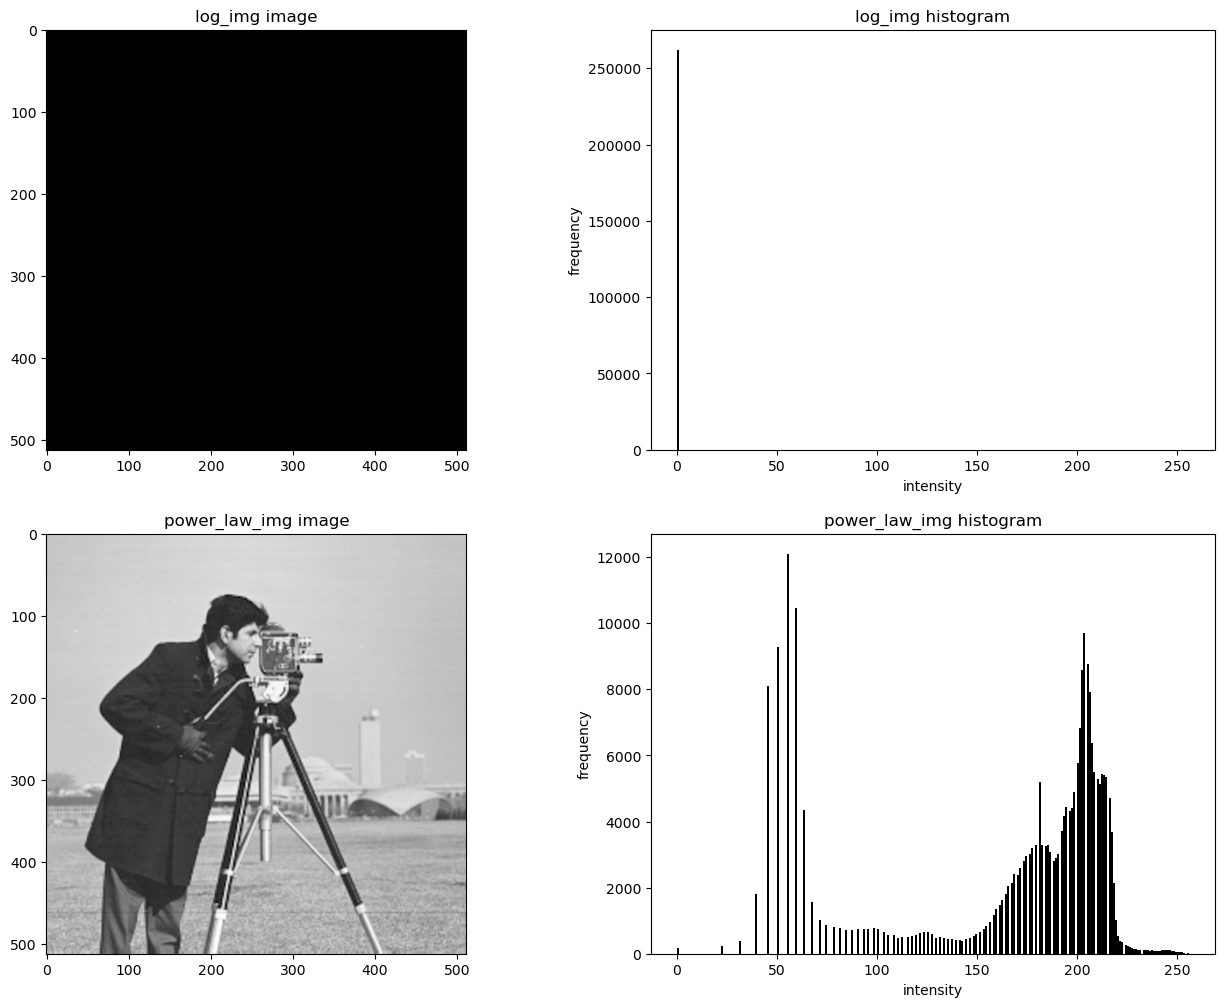

In [5]:
c = 255/np.log(1+np.max(img))
log_img = c* np.log((1+img))
log_img = log_img.astype(np.uint8)

gamma = 0.5
power_law_img = np.power(img/255, gamma)*255
power_law_img = power_law_img.astype(np.uint8)

plt.figure(figsize=(16,12))

plt.subplot(2,2,1)
plt.imshow(log_img, cmap='gray')
plt.title('log_img image')

plt.subplot(2,2,2)
plt.hist(log_img.ravel(), bins=256, range=(0,256), color='black')
plt.title('log_img histogram')
plt.xlabel('intensity')
plt.ylabel('frequency')


plt.subplot(2,2,3)
plt.imshow(power_law_img, cmap='gray')
plt.title('power_law_img image')

plt.subplot(2,2,4)
plt.hist(power_law_img.ravel(), bins=256, range=(0,256), color='black')
plt.title('power_law_img histogram')
plt.xlabel('intensity')
plt.ylabel('frequency')


(c) Find the difference image between original and the image obtained by last three bits (MSB)

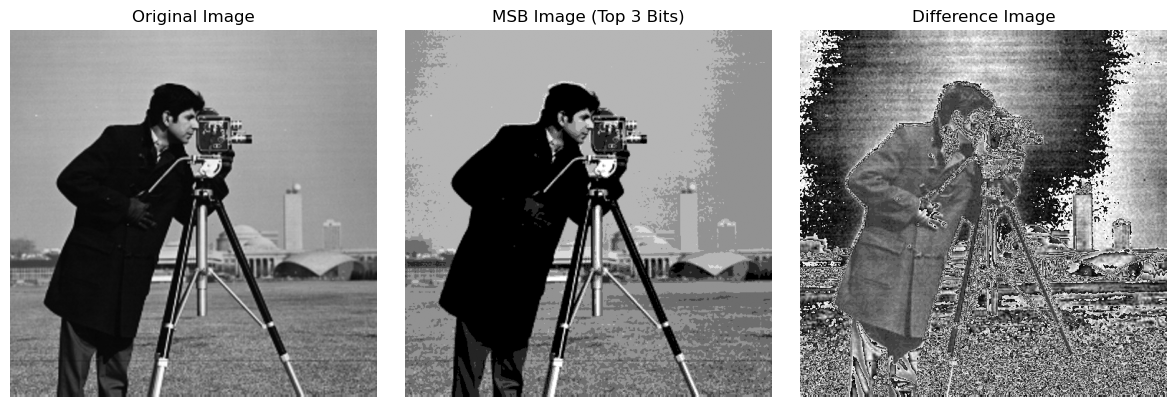

In [7]:
msb_bits = img>>5
msb_img = msb_bits<<5

diff_img = cv2.absdiff(img, msb_img)

# Display results
plt.figure(figsize=(12,4))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("MSB Image (Top 3 Bits)")
plt.imshow(msb_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Difference Image")
plt.imshow(diff_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()